# Clustering

# 1. Overview
+ Clustering is an unsupervised learning technique that groups similar data points together based on their features.
+ **Goal**: To partition a dataset into **distinct groups (clusters)** such that data points within the same cluster are more similar to each other than to those in other clusters.
---
+ Types of clustering Methods:
  + **Partitional Clustering(划分聚类)**: 
    + Divides data into non-overlapping subsets (e.g., K-means).
    + Each data point belongs to exactly one cluster.
  + **Hierarchical Clustering(层次聚类)**: 
    + Builds a tree of clusters (e.g., Agglomerative, Divisive).
---
+ Types of Clusters:
  + **Well-separated Clusters(分离良好的聚类)**: 
    + Any pair of data points from different clusters are farther apart than any pair of data points from the same cluster.
  + **Center-based Clustering(基于中心的聚类)**: 
    + Clusters are defined by a central point (e.g., K-means).
    + The data points in a cluster are closer to the cluster center than to any other cluster center.
  + **Contigouous Clustering(连续聚类)**: 
    + Clusters are defined by connected regions in the feature space (e.g., DBSCAN).
    + The data points in a cluster are connected to each other by paths of neighboring points.
  + **Density-based Clustering(基于密度的聚类)**: 
    + Clusters are defined as areas of higher density than the remainder of the data set (e.g., DBSCAN).
    + Clusters are formed by connecting areas of high density, and noise points are those that do not belong to any cluster.
  + **Objective Function Clustering(基于目标函数的聚类)**: 
    + Clusters are defined by optimizing a specific objective function (e.g., K-means minimizes the within-cluster sum of squares).
    + The goal is to find a partition of the data that **minimizes (or maximizes)** the objective function.
    + There are two types of objective functions:
      + **Local Objective Function(局部目标函数)**: 
        + Depends only on the data points in the same cluster (e.g., K-means).
      + **Global Objective Function(全局目标函数)**: 
        + Depends on the data points in all clusters (e.g., Spectral Clustering).

# 2. Algorithms of Clustering

## 2.1 K-means Clustering
+ Partitional clustering
+ Center-based clustering
+ Objective function clustering (local objective function)

+ **Core idea**:
  + Each cluster is associated with a centroid (the mean of the data points in the cluster).
  + Each data point is assigned to the cluster with the nearest centroid.

### 2.1.1 Algorithm:
+ **Input**: 
  + A set of data points $X = \{x_1, x_2, ..., x_n\}$ where $x_i \in \mathbb{R}^d$
  + The number of clusters $K$.
+ **Output**: 
  + A partition of the data points into $K$ clusters $C = \{C_1, C_2, ..., C_K\}$.
+ **Steps**:
  1. **Initialization**: 
    + Randomly select $K$ data points as the initial centroids $\mu_1, \mu_2, ..., \mu_K$.
  2. **Assignment Step**: 
    + For each data point $x_i$, assign it to the cluster with the nearest centroid:
    $$C_j = \{x_i : \|x_i - \mu_j\|^2 \leq \|x_i - \mu_k\|^2 \text{ for all } k = 1, 2, ..., K\}$$
  3. **Update Step**: 
    + For each cluster $C_j$, update the centroid $\mu_j$ to be the mean of the data points in the cluster:
    $$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$
  4. **Repeat**: 
    + Repeat steps 2 and 3 until convergence (i.e., when the centroids won't change anymore).
    + Which also means that the centroids are the geometric median of the data points in the cluster.
+ **Time complexity**: $O(nKId)$ where:
  + $n$ is the number of data points,
  + $K$ is the number of clusters,
  + $I$ is the number of iterations until convergence,
  + $d$ is the dimensionality of the data.

+ Many details:
  + Because the first step is random, the output of K-means isn't deterministic. 
  + The results also depend on the number of clusters $K$.
  + In practice, K-means offen converges in a few iterations($5~10$). So we also set some stop condictions like:
    + Maximum number of iterations.
    + Minimum change in centroids(The change of centroids is less than a threshold).
    + Minimum number of changes of cluster.(Only a few cluster assignments change).

### 2.1.2 Use K-means in practice:
+ Objective Function:
  + Most common performance measure of k-means is **Sum of Squared Error (SSE)**. For each data point, the error is defined as the distance to the nearest cluster center. So the objective function is:
  $$
  SSE = \sum_{i=1}^K \sum_{x \in C_i} \|x - \mu_i\|^2
  $$
  + Obviously, the goal of K-means is to minimize the SSE. The cluster with the smallest SSE is the best clustering result.
+ Choosing $K$:
  + When $K$ increases, the SSE will decrease. Consider the extreme case when $K=n$, each data point is its own cluster, then the SSE will be $0$. So we need to balance the number of clusters and the SSE. One common method is to use the **Elbow Method** to find the optimal number of clusters.
  + Elbow Method:
    + Core idea:
      + When $K$ increases, the SSE will decrease. But the rate of decrease will slow down after a certain point. The point where the rate of decrease slows down is called the "elbow point". The optimal number of clusters is at the elbow point.
      + That $K$ is considered to be the optimal number of clusters because it provides a good balance between the SSE and the number of clusters.
+ Initialization of centroids:
  + The random initialization of centroids can lead to different results. Here are some common solutions to improve the initialization:
    + **Multiple runs**: 
      + Run K-means multiple times with different random initializations and choose the best result (the one with the lowest SSE).
    + **Sample & Use Hierarchical Clustering**: 
      + Sampling a subset of the original data.
      + Apply hierarchical clustering to the sample to find initial centroids.
    + **K-means++**:
      + Randomly choose $M>K$ data points as candidates for centroids.
      + Find the most scattered $K$ points among the candidates to be the initial centroids.
    + **Post-processing**:
      + After running K-means, check the results.
      + If some clusters are empty, reinitialize the centroids of those clusters and run K-means again.
      + If some clusters have huge SSE, partition those clusters.
    + **Bisecting K-means**:
      + Start with all data points in one cluster.
      + Iteratively split the cluster with the highest SSE into two clusters using K-means until $K$ clusters are formed.
+ Handling empty clusters:
  + Choose the point with the largest contribution to the SSE.
    + Find the point that take the largest contribution to the SSE (i.e., the point that is farthest from its assigned cluster center).
    + Reassign that point to the empty cluster and update the cluster centers.
  + Select at the cluster with the largest SSE.
    + Find the cluster with the largest SSE, select the data point in it that is farthest from the cluster center.
    + Reassign that point to the empty cluster and update the cluster centers.
+ Update of centroids:
  + Standard K-means:
    + Each round/iteration, update all the cluster centers after assigning all data points to clusters.
  + Online K-means:
    + Update the cluster center immediately after assigning each data point to a cluster.
    + Pros:
      + Converges faster in practice.
      + Never produces empty clusters.
    + Cons:
      + More sensitive to the order of data points.
      + Bigger computational cost per iteration.
+ Pre-processing:
  + Standardization:
    + Standardization can be done by subtracting the mean and dividing by the standard deviation for each feature.
  + Remove outliers:
    + Outliers can be detected using methods like Z-score, IQR, or visual inspection.
+ Post-processing:
  + Remove the tiny clusters (clusters with very few data points) if they are not meaningful.
  + Merge the small clusters if they are close to each other and have similar characteristics.
  + Split the large clusters if they have high SSE and are not well-separated.

### 2.1.3 Limitations of K-means:
+ Sensitivity to the size of clusters:
  + K-means tends to create clusters of similar size, which can be problematic if the true clusters in the data have different sizes.
+ Can't deal with non-convex clusters:
  + K-means assumes that clusters are convex and isotropic (i.e., they have the same variance in all directions). It may fail to capture the structure of non-convex clusters.
+ Sensitivity to outliers:
  + K-means is sensitive to outliers because it uses the mean to update the cluster centers. Outliers can significantly affect the position of the cluster centers and lead to poor clustering results.

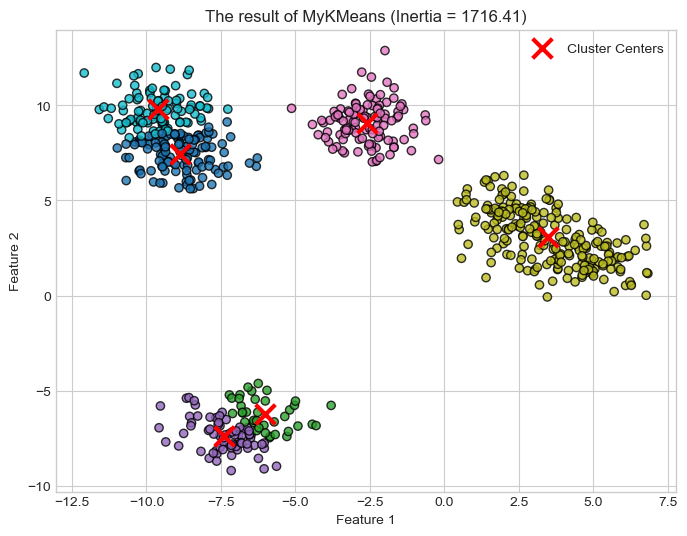

In [30]:
from sklearn.utils import check_array
from sklearn.base import BaseEstimator, ClusterMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd


class MyKMeans(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=8, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y=None):
        X = check_array(X, dtype=[np.float64, np.float32])
        n_samples, n_features = X.shape
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than n_samples.")
        
        rng = np.random.default_rng(self.random_state)
        self.cluster_centers_ = X[rng.choice(n_samples, self.n_clusters, replace=False)]
        
        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
            self.labels_ = np.argmin(distances, axis=1)
            
            new_centers = np.zeros_like(self.cluster_centers_)
            for i in range(self.n_clusters):
                cluster_points = X[self.labels_ == i]
                if len(cluster_points) > 0:
                    new_centers[i] = cluster_points.mean(axis=0)
                else:
                    new_centers[i] = X[rng.choice(n_samples)]
            
            if np.allclose(self.cluster_centers_, new_centers):
                break
                
            self.cluster_centers_ = new_centers

        self.n_features_in_ = n_features
        self.inertia_ = np.sum((X - self.cluster_centers_[self.labels_]) ** 2)
        
        return self
    
    def fit_predict(self, X, y=None):
        return self.fit(X).labels_
    
    
def visualize(cluster, n_samples=666, centers=6, cluster_std=1.0, random_state=42):
    plt.style.use('seaborn-v0_8-whitegrid')
    X, _ = make_blobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=random_state)

    labels = cluster.fit_predict(X)


    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', alpha=0.8, edgecolor='k')
    plt.scatter(cluster.cluster_centers_[:, 0], cluster.cluster_centers_[:, 1],
                c='red', marker='x', s=200, linewidths=3, label='Cluster Centers')
    plt.title(f'The result of MyKMeans (Inertia = {cluster.inertia_:.2f})')
    plt.legend()
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

kmeans = MyKMeans(n_clusters=6, random_state=42)
visualize(kmeans)


## 2.2 Hierarchical Clustering
+ **Core Idea**: 
  + Build a hierarchy of clusters, organize data points into a tree of clusters.
  + After building the hierarchy, we can choose the level of the hierarchy to get the desired number of clusters.
  + Two main types:
    + **Agglomerative Hierarchical Clustering(凝聚层次聚类)**: 
      + From the bottom up.
      + Start with **each data point as its own cluster** and iteratively merge the closest clusters until **only one cluster remains**.
    + **Divisive Hierarchical Clustering(分裂层次聚类)**: 
      + From the top down.
      + Start with **all data points in one cluster** and iteratively split the cluster with the highest SSE until **each data point is its own cluster**.
+ **Algorithm steps**:
+ **Input**:
  + A set of data points $X = \{x_1, x_2, ..., x_n\}$ where $x_i \in \mathbb{R}^d$.
+ **Output**:
  + A hierarchy of clusters represented as a dendrogram (a tree-like diagram).

### 2.2.1 Divisive Hierarchical Clustering:
1. Start with all data points in one cluster (initially, there is one cluster).
2. Repeat the following steps until each data point is its own cluster:
   1. Choose a cluster by some criterion.
   2. Split the cluster with the highest SSE into two clusters using a method like K-means.
3. The result is a hierarchy of clusters represented as a dendrogram.

The key point of the divisive hierarchical clustering is: **How to choose the cluster to split?** Obviously, the different criteria will lead to different clustering results. Here are some common criteria:
+ **SSE**:
  + Choose the cluster with the highest SSE to split.
  + Pros:
    + Focuses on improving the cluster with the worst fit.
  + Cons:
    + Can lead to unbalanced splits if one cluster has a much higher SSE than others.
+ **Size**:
  + Choose the cluster with the largest number of data points to split.
  + Pros:
    + Ensures that larger clusters are split first, which can lead to more balanced clusters.
  + Cons:
    + May not always lead to the best clustering results, as it doesn't consider the quality of the clusters.
+ **diameter**:
  + Choose the cluster with the largest diameter (the maximum distance between any two data points in the cluster) to split.
  + Pros:
    + Focuses on splitting clusters that are more spread out.
  + Cons:
    + Can be sensitive to outliers, as they can significantly increase the diameter of a cluster.

### 2.2.2 Agglomerative Hierarchical Clustering:
1. Regard each data point as a cluster (initially, there are $n$ clusters).
2. Repeat the following steps until only one cluster remains:
   1. Compute the distance between all pairs of clusters.
   2. Merge the two **closest** clusters into a single cluster.
3. The result is a hierarchy of clusters represented as a dendrogram.

The key point of the agglomerative hierarchical clustering is: **How to measure the distance between clusters?** Obviously the different distance measures will lead to different clustering results. Here are some common distance measures:
+ **Minimum Distance (Single Linkage, 单链接)**:
  + Based on the minimum distance between data points in different clusters.
  + Pros:
    + Can capture non-convex clusters.
  + Cons:
    + Sensitive to noise and outliers.
+ **Maximum Distance (Complete Linkage, 全链接)**:
  + Based on the maximum distance between data points in different clusters.
  + Pros:
    + Produces more compact clusters.
  + Cons:
    + Can fail to capture non-convex clusters.
    + Leans towards producing clusters of similar size.
+ **Average Distance (平均链接)**:
  + Based on the average distance between all pairs of data points in different clusters.
  + Pros:
    + Provides a balance between single and complete linkage.
    + Less sensitive to noise and outliers than single linkage.
  + Cons:
    + Can still produce clusters of similar size.
+ **Ward's Method (ward法)**:
  + Based on the increase in SSE when two clusters are merged.
  + Pros:
    + Tends to produce clusters of similar size.
    + Can capture non-convex clusters.
  + Cons:
    + Sensitive to outliers.
+ **Centroid Distance (质心距离)**:
  + Based on the distance between the centroids of clusters.
  + Pros:
    + Simple to compute.
  + Cons:
    + Can fail to capture non-convex clusters.
    + Sensitive to outliers.

### 2.2.3 Minimum Spanning Tree (MST) Clustering:
+ **Core Idea**:
  + Construct a minimum spanning tree (MST) from the data points, where the weight of the edge between two data points is the distance between them.
  + Remove the $K-1$ longest edges from the MST to form $K$ clusters.
+ **Algorithm steps**:
1. Start from any point as the root of the tree.
2. Use Prim's or Kruskal's algorithm to construct the MST.
3. Remove the $K-1$ longest edges from the MST to form $K$ clusters.

In [31]:
class MyHierarchicalClustering(BaseEstimator, ClusterMixin):
    def __init__(self, type='Agglomerative', measure='MIN', split_criterion='diameter', n_clusters=2, random_state=42):
        if type not in ['Agglomerative', 'Divisive', 'MST']:
            raise ValueError("type must be 'Agglomerative', 'Divisive', or 'MST'.")

        if type == 'Agglomerative':
            if measure == 'MIN':
                self.measure_func = self._min_distance
            elif measure == 'MAX':
                self.measure_func = self._max_distance
            elif measure == 'AVG':
                self.measure_func = self._avg_distance
            elif measure == 'WARD':
                self.measure_func = self._ward_distance
            elif measure == 'CENTROID':
                self.measure_func = self._centroid_distance
            else:
                raise ValueError("For Agglomerative clustering, measure must be 'MIN', 'MAX', 'AVG', 'WARD', or 'CENTROID'.")
        elif type == 'Divisive':
            if split_criterion == 'diameter':
                self.split_criterion_func = self._find_biggest_diameter_cluster
            elif split_criterion == 'SSE':
                self.split_criterion_func = self._find_highest_sse_cluster
            elif split_criterion == 'size':
                self.split_criterion_func = self._find_biggest_size_cluster
            else:
                raise ValueError("For Divisive clustering, split_criterion must be 'diameter', 'SSE', or 'size'.")

        self.type = type
        self.measure = measure
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.split_criterion = split_criterion

    def fit(self, X, y=None):
        X = check_array(X, dtype=[np.float64, np.float32])
        n_samples, n_features = X.shape
        self.n_features_in_ = n_features

        if not (1 <= self.n_clusters <= n_samples):
            raise ValueError("n_clusters must be in [1, n_samples].")

        if self.type == 'Agglomerative':
            return self._agglomerative_clustering(X)
        elif self.type == 'Divisive':
            return self._divisive_clustering(X)
        else:
            return self._mst_clustering(X)

    def fit_predict(self, X, y=None):
        return self.fit(X, y).labels_

    def _finalize_partition_by_clusters(self, X):
        self.labels_ = np.empty(X.shape[0], dtype=int)
        for label, cluster in enumerate(self._clusters):
            self.labels_[cluster] = label

        self.clusters_ = [np.array(cluster, dtype=int) for cluster in self._clusters]
        self.cluster_centers_ = np.vstack([X[cluster].mean(axis=0) for cluster in self.clusters_])
        self.inertia_ = np.sum((X - self.cluster_centers_[self.labels_]) ** 2)

    def _finalize_partition_by_labels(self, X):
        unique_labels = np.unique(self._labels)
        label_map = {old: new for new, old in enumerate(unique_labels)}
        self.labels_ = np.array([label_map[v] for v in self._labels], dtype=int)

        n_clusters_found = len(unique_labels)
        self.clusters_ = [np.where(self.labels_ == i)[0] for i in range(n_clusters_found)]
        self._clusters = [cluster.copy() for cluster in self.clusters_]
        self.cluster_centers_ = np.vstack([X[cluster].mean(axis=0) for cluster in self.clusters_])
        self.inertia_ = np.sum((X - self.cluster_centers_[self.labels_]) ** 2)

    def _agglomerative_clustering(self, X):
        self._clusters = [np.array([i], dtype=int) for i in range(X.shape[0])]

        while len(self._clusters) > self.n_clusters:
            i, j = self._find_closest_clusters(X)
            self._merge_clusters(i, j)

        self._finalize_partition_by_clusters(X)
        return self

    def _find_closest_clusters(self, X):
        min_distance = np.inf
        closest_clusters = (0, 1)

        for i in range(len(self._clusters)):
            for j in range(i + 1, len(self._clusters)):
                distance = self.measure_func(X, self._clusters[i], self._clusters[j])
                if distance < min_distance:
                    min_distance = distance
                    closest_clusters = (i, j)

        return closest_clusters

    def _min_distance(self, X, cluster1, cluster2):
        min_distance = np.inf
        for idx1 in cluster1:
            for idx2 in cluster2:
                distance = np.linalg.norm(X[idx1] - X[idx2])
                if distance < min_distance:
                    min_distance = distance
        return min_distance

    def _max_distance(self, X, cluster1, cluster2):
        max_distance = -np.inf
        for idx1 in cluster1:
            for idx2 in cluster2:
                distance = np.linalg.norm(X[idx1] - X[idx2])
                if distance > max_distance:
                    max_distance = distance
        return max_distance

    def _avg_distance(self, X, cluster1, cluster2):
        total_distance = 0.0
        count = 0
        for idx1 in cluster1:
            for idx2 in cluster2:
                total_distance += np.linalg.norm(X[idx1] - X[idx2])
                count += 1
        return total_distance / count if count > 0 else 0.0

    def _ward_distance(self, X, cluster1, cluster2):
        centroid1 = X[cluster1].mean(axis=0)
        centroid2 = X[cluster2].mean(axis=0)
        n1, n2 = len(cluster1), len(cluster2)
        return (n1 * n2) / (n1 + n2) * np.sum((centroid1 - centroid2) ** 2)

    def _centroid_distance(self, X, cluster1, cluster2):
        centroid1 = X[cluster1].mean(axis=0)
        centroid2 = X[cluster2].mean(axis=0)
        return np.linalg.norm(centroid1 - centroid2)

    def _merge_clusters(self, i, j):
        self._clusters[i] = np.concatenate((self._clusters[i], self._clusters[j]))
        del self._clusters[j]

    def _divisive_clustering(self, X):
        self._clusters = [np.arange(X.shape[0], dtype=int)]
        splitter = MyKMeans(n_clusters=2, random_state=self.random_state)
        rng = np.random.default_rng(self.random_state)

        while len(self._clusters) < self.n_clusters:
            cluster_to_split = self.split_criterion_func(X)
            if cluster_to_split is None:
                break

            cluster_indices = self._clusters[cluster_to_split]
            if len(cluster_indices) <= 1:
                break

            splitter.fit(X[cluster_indices])
            split_labels = splitter.labels_
            left = cluster_indices[split_labels == 0]
            right = cluster_indices[split_labels == 1]

            if len(left) == 0 or len(right) == 0:
                shuffled = cluster_indices.copy()
                rng.shuffle(shuffled)
                mid = len(shuffled) // 2
                left, right = shuffled[:mid], shuffled[mid:]
                if len(left) == 0 or len(right) == 0:
                    break

            self._clusters[cluster_to_split] = left
            self._clusters.append(right)

        self._finalize_partition_by_clusters(X)
        return self

    def _find_biggest_diameter_cluster(self, X):
        max_diameter = -np.inf
        cluster_to_split = None
        for i, cluster in enumerate(self._clusters):
            if len(cluster) <= 1:
                continue
            points = X[cluster]
            diameter = np.max(np.linalg.norm(points[:, np.newaxis] - points[np.newaxis, :], axis=2))
            if diameter > max_diameter:
                max_diameter = diameter
                cluster_to_split = i
        return cluster_to_split

    def _find_highest_sse_cluster(self, X):
        max_sse = -np.inf
        cluster_to_split = None
        for i, cluster in enumerate(self._clusters):
            if len(cluster) <= 1:
                continue
            points = X[cluster]
            centroid = points.mean(axis=0)
            sse = np.sum(np.linalg.norm(points - centroid, axis=1) ** 2)
            if sse > max_sse:
                max_sse = sse
                cluster_to_split = i
        return cluster_to_split

    def _find_biggest_size_cluster(self, X):
        max_size = -np.inf
        cluster_to_split = None
        for i, cluster in enumerate(self._clusters):
            if len(cluster) <= 1:
                continue
            size = len(cluster)
            if size > max_size:
                max_size = size
                cluster_to_split = i
        return cluster_to_split

    def _mst_clustering(self, X):
        n = X.shape[0]
        dist_matrix = np.linalg.norm(X[:, np.newaxis] - X[np.newaxis, :], axis=2)

        in_tree = np.zeros(n, dtype=bool)
        min_dist = np.full(n, np.inf)
        parent = np.full(n, -1, dtype=int)
        min_dist[0] = 0.0

        edges = []
        for _ in range(n):
            u = int(np.argmin(np.where(in_tree, np.inf, min_dist)))
            in_tree[u] = True

            if parent[u] != -1:
                edges.append((parent[u], u, dist_matrix[parent[u], u]))

            for v in range(n):
                if not in_tree[v] and dist_matrix[u, v] < min_dist[v]:
                    min_dist[v] = dist_matrix[u, v]
                    parent[v] = u

        edges_sorted = sorted(edges, key=lambda x: x[2], reverse=True)
        cut_count = max(0, min(self.n_clusters - 1, len(edges_sorted)))
        removed_edges = set((u, v) for u, v, _ in edges_sorted[:cut_count])
        removed_edges.update((v, u) for u, v, _ in edges_sorted[:cut_count])

        root = np.arange(n, dtype=int)

        def find(a):
            while root[a] != a:
                root[a] = root[root[a]]
                a = root[a]
            return a

        def union(a, b):
            ra, rb = find(a), find(b)
            if ra != rb:
                root[rb] = ra

        for u, v, _ in edges:
            if (u, v) not in removed_edges:
                union(u, v)

        comp_map = {}
        self._labels = np.empty(n, dtype=int)
        next_label = 0
        for i in range(n):
            r = find(i)
            if r not in comp_map:
                comp_map[r] = next_label
                next_label += 1
            self._labels[i] = comp_map[r]

        self._finalize_partition_by_labels(X)
        return self

[diameter] unique labels: [0 1 2 3], sizes: [30 30 30 30]
[SSE] unique labels: [0 1 2 3], sizes: [30 30 30 30]
[size] unique labels: [0 1 2 3], sizes: [30 30 30 30]


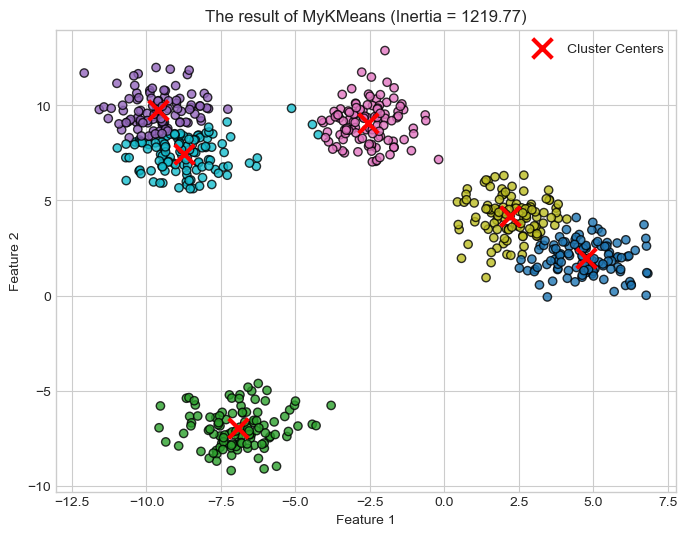

In [32]:
X_div, _ = make_blobs(n_samples=120, centers=4, cluster_std=0.75, random_state=42)

for criterion in ['diameter', 'SSE', 'size']:
    model = MyHierarchicalClustering(
        type='Divisive',
        split_criterion=criterion,
        n_clusters=4,
        random_state=42
    )
    labels = model.fit_predict(X_div)
    print(f'[{criterion}] unique labels: {np.unique(labels)}, sizes: {np.bincount(labels)}')

# Compatibility check with existing visualize() helper.
visualize(MyHierarchicalClustering(type='Divisive', split_criterion='SSE', n_clusters=6, random_state=42))